# Análisis Discriminante Lineal

El objetivo es mostrar la clasificación con LDA.

#### Bibliotecas necesarias

In [1]:
#General
import numpy as np
import pandas as pd
from skimpy import skim

#Estadisticas
from scipy import stats

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import andrews_curves

from matplotlib.colors import ListedColormap

from plotnine import ggplot, aes, geom_boxplot, geom_density, facet_wrap, theme_bw, labs, ggtitle


#Valores atipicos
from pyod.models.mcd import MCD

#Modelo de clasificacion
from sklearn.preprocessing import MinMaxScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score, make_scorer
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split,cross_val_score

#### Opciones globales

In [2]:
np.random.seed(1989)

In [3]:
pd.options.display.float_format = '{:,.3f}'.format

In [4]:
%matplotlib inline

### Carga de datos

In [5]:
df = pd.read_csv(r"C:\Users\raulb\Desktop\Diplomado\Modulo2\Datos\iris.csv")

In [6]:
df.sample(10)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
121,5.600,2.800,4.900,2.000,virginica
59,5.200,2.700,3.900,1.400,versicolor
105,7.600,3.000,6.600,2.100,virginica
89,5.500,2.500,4.000,1.300,versicolor
10,5.400,3.700,1.500,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
78,6.000,2.900,4.500,1.500,versicolor
146,6.300,2.500,5.000,1.900,virginica
47,4.600,3.200,1.400,0.200,setosa
88,5.600,3.000,4.100,1.300,versicolor


In [7]:
#Transformamos en categorica
df["Species"] = df["Species"].astype("category")

In [8]:
#Breve resumen
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 150    │ │ float64     │ 4     │ │ Species               │                                │
│ │ Number of columns │ 5      │ │ category    │ 1     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column            ┃ NA   ┃ NA %   ┃ mean     ┃ sd        ┃ p0    ┃ p25   ┃ p50    ┃ p75  ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ Sepal.Length      │    0 │      0 │    5.843 │    0.8281 │   4.3 │   5.1 │    5.8 │  6.4 │   7.9 │ ▃▇▇▇▅▂  │  │
│ │ Sepal.Width       │    0 │      0 │    3.057 │    0.4359 │     2 │   2.8 │      3 │  3.3 │   4.4 │ ▁▇▇▇▂▁  │  │
│ │ Petal.Length      │    0 │      0 │    3.758 │     1.765 │     1 │   1.6 │   4.35 │  5.1 │   6.9 │ ▇ ▂▇▆▂  │  │
│ │ Petal.Width       │    0 │      0 │    1.199 │    0.7622 │   0.1 │   0.3 │    1.3 │  1.8 │   2.5 │ ▇ ▂▆▅▃  │  │
│ └───────────────────┴──────┴────────┴──────────┴───────────┴───────┴───────┴────────┴──────┴───────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                   ┃ NA         ┃ NA %             ┃ ordered                  ┃ unique               ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Species                  │          0 │                0 │ False                    │                    3 │  │
│ └──────────────────────────┴────────────┴──────────────────┴──────────────────────────┴──────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

## EDA

In [9]:
var_cat = ["Species"]
var_num = list(set(df.columns) - set(var_cat))

In [10]:
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars):
        self.df = df
        self.num_vars = num_vars

    # Método para graficar variables numéricas 
    def plot_num(self, explicativa=None):
        for var in self.num_vars:
            if explicativa and explicativa in self.df.columns:
                # Boxplot por categoría
                p1 = (
                    ggplot(self.df, aes(x=explicativa, y=var, fill=explicativa))
                    + geom_boxplot(alpha=0.6, outlier_color="red")
                    + theme_bw()
                    + labs(title=f"Boxplot {var}", x=explicativa, y=var)
                )

                # Densidad por categoría
                p2 = (
                    ggplot(self.df, aes(x=var, fill=explicativa))
                    + geom_density(alpha=0.6)
                    + theme_bw()
                    + labs(title=f"Densidad {var}", x=var, y="Densidad")
                )

            else:
                # Boxplot simple
                p1 = (
                    ggplot(self.df, aes(y=var))
                    + geom_boxplot(fill="#de3163", alpha=0.6)
                    + theme_bw()
                    + labs(title=f"Boxplot de {var}", y=var)
                )

                # Densidad simple
                p2 = (
                    ggplot(self.df, aes(x=var))
                    + geom_density(fill="#31deac", alpha=0.6)
                    + theme_bw()
                    + labs(title=f"Densidad de {var}", x=var, y="Densidad")
                )

            # Mostrar gráficos
            display(p1)
            display(p2)

    # Método para graficar la matriz de correlación
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='inferno', fmt=".2f")
        plt.title("Matriz de Correlación")
        plt.show()

In [11]:
analisis = analyze(df, var_num)

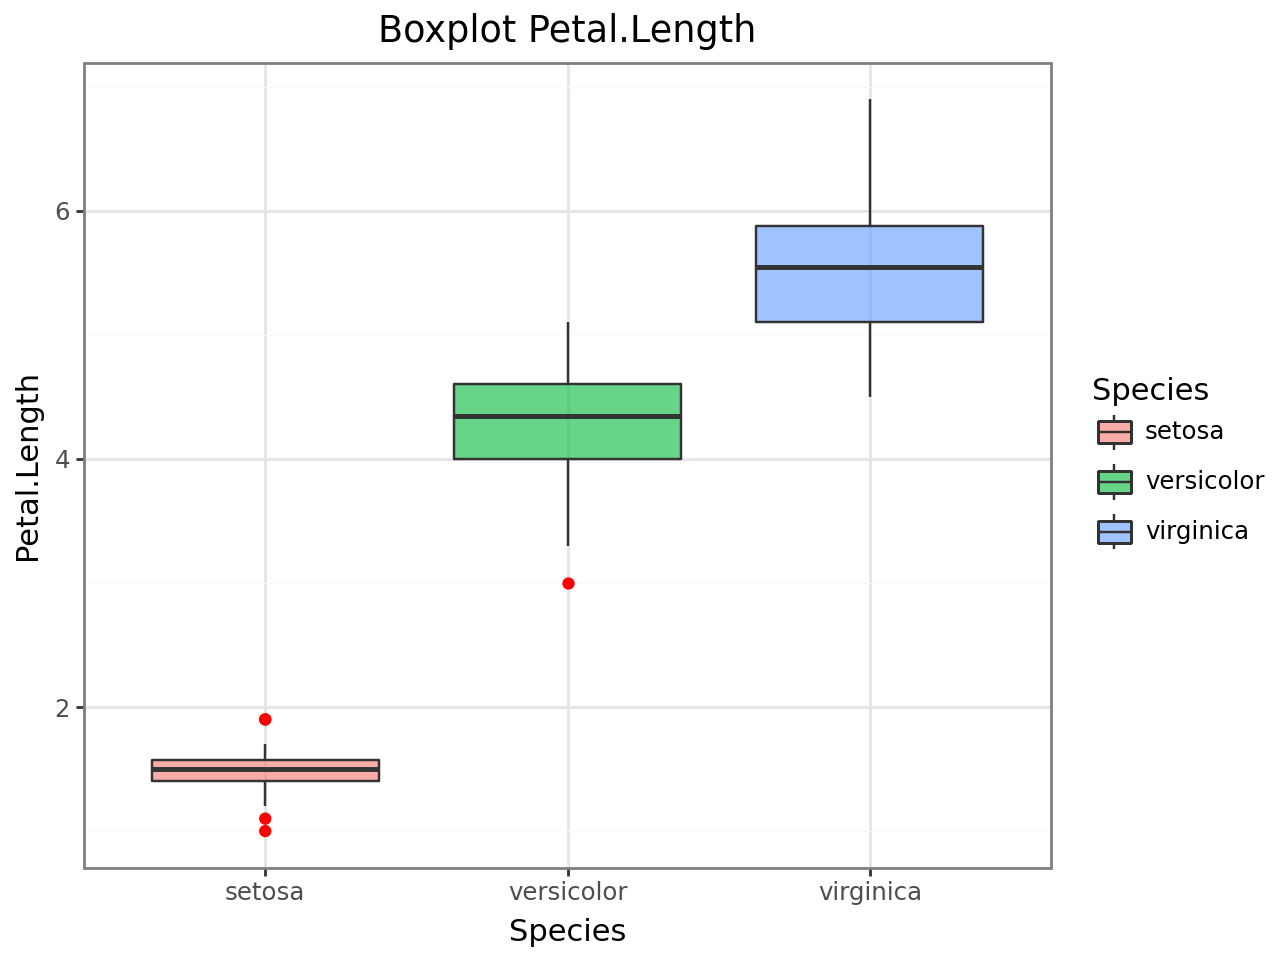

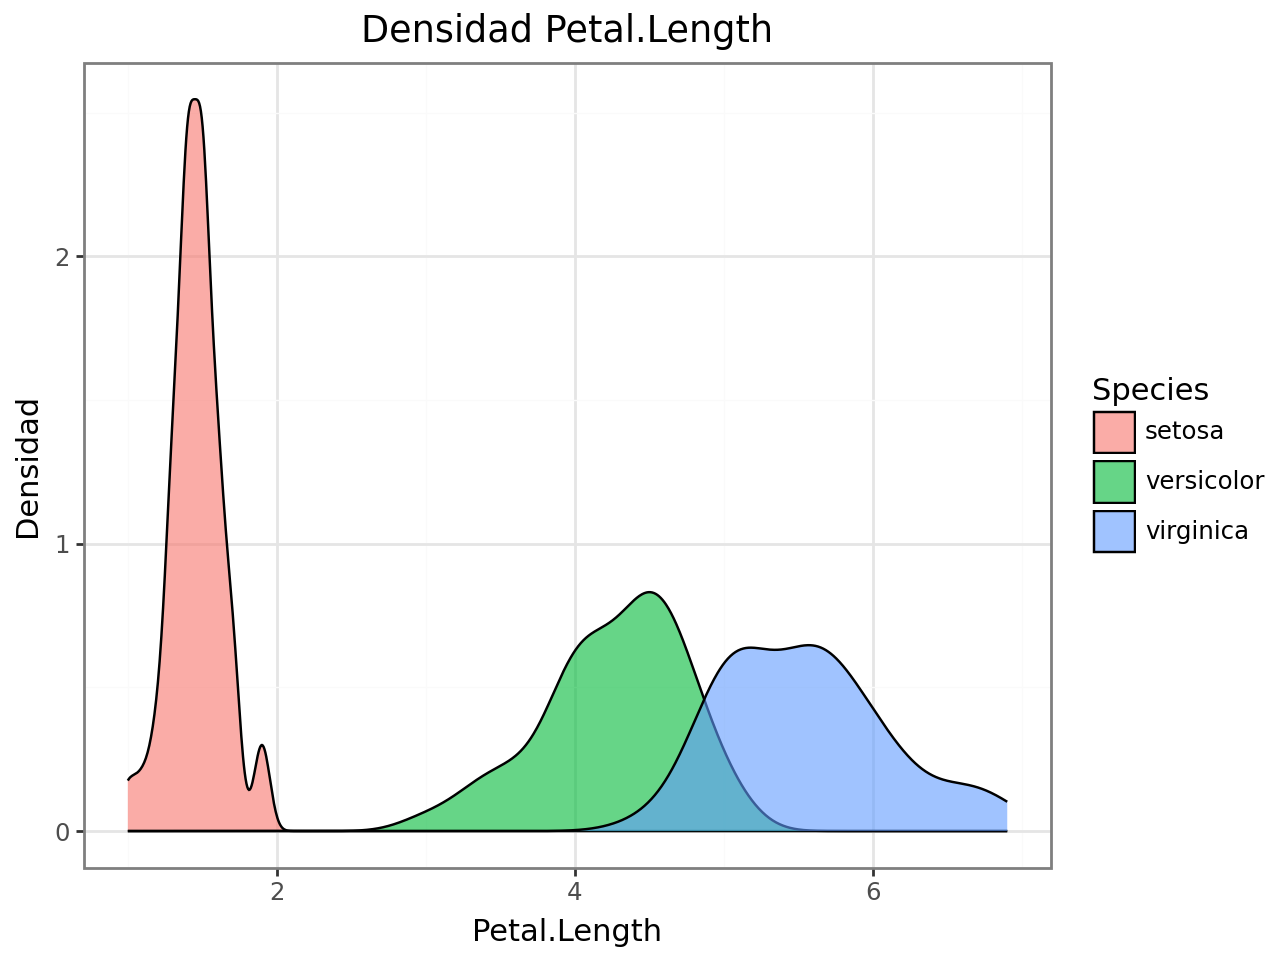

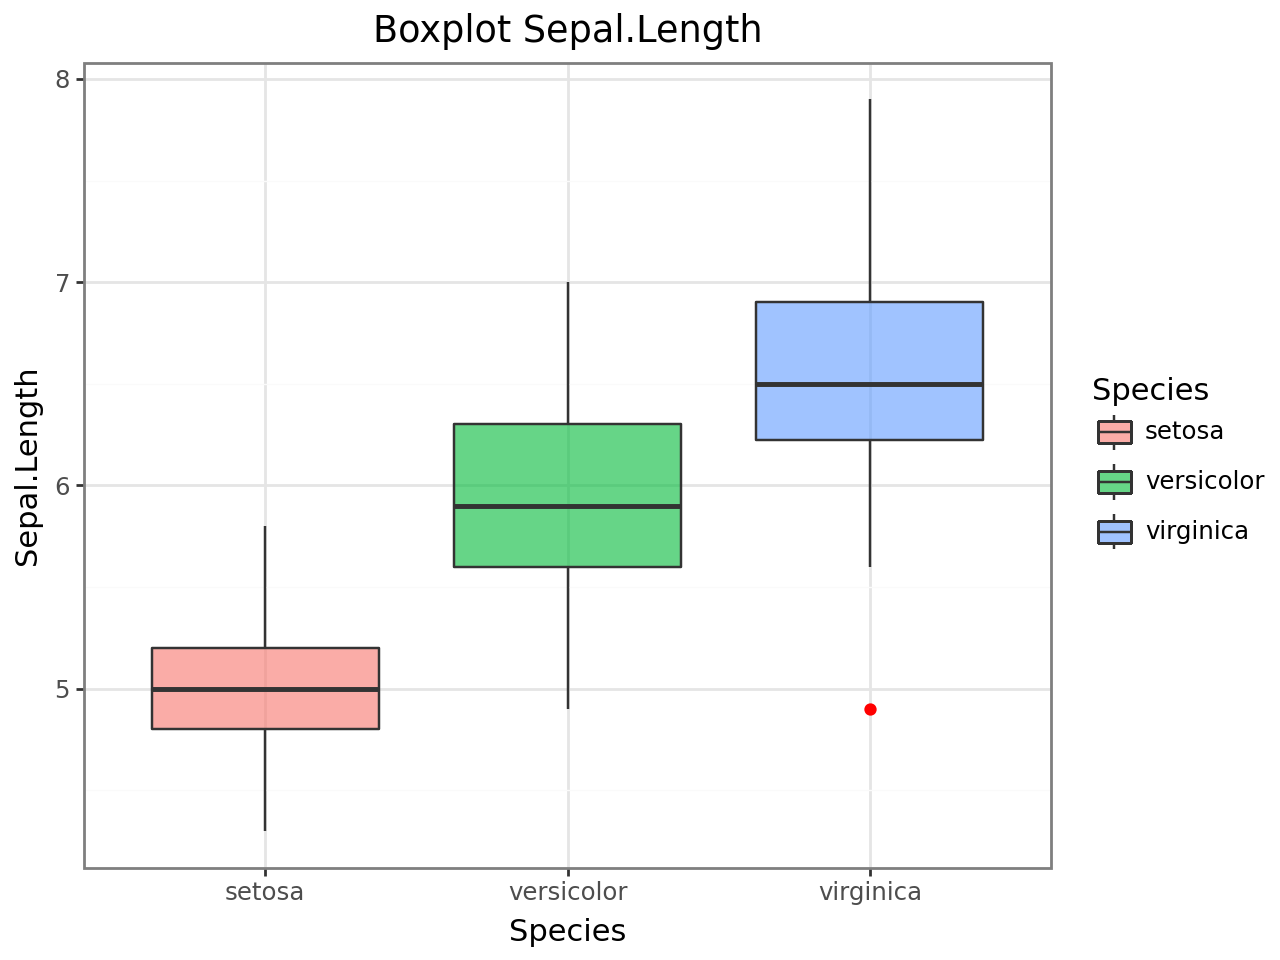

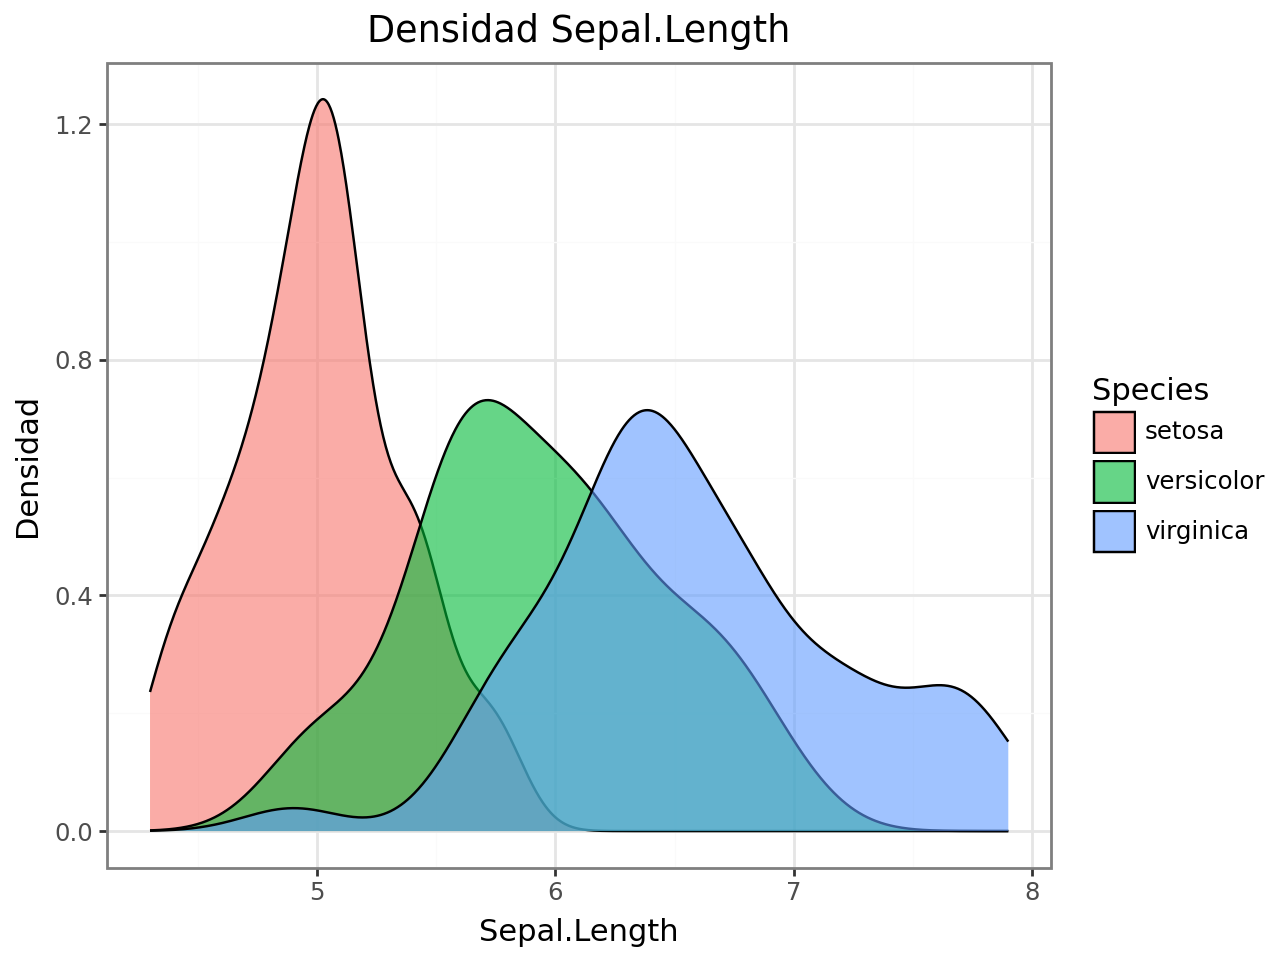

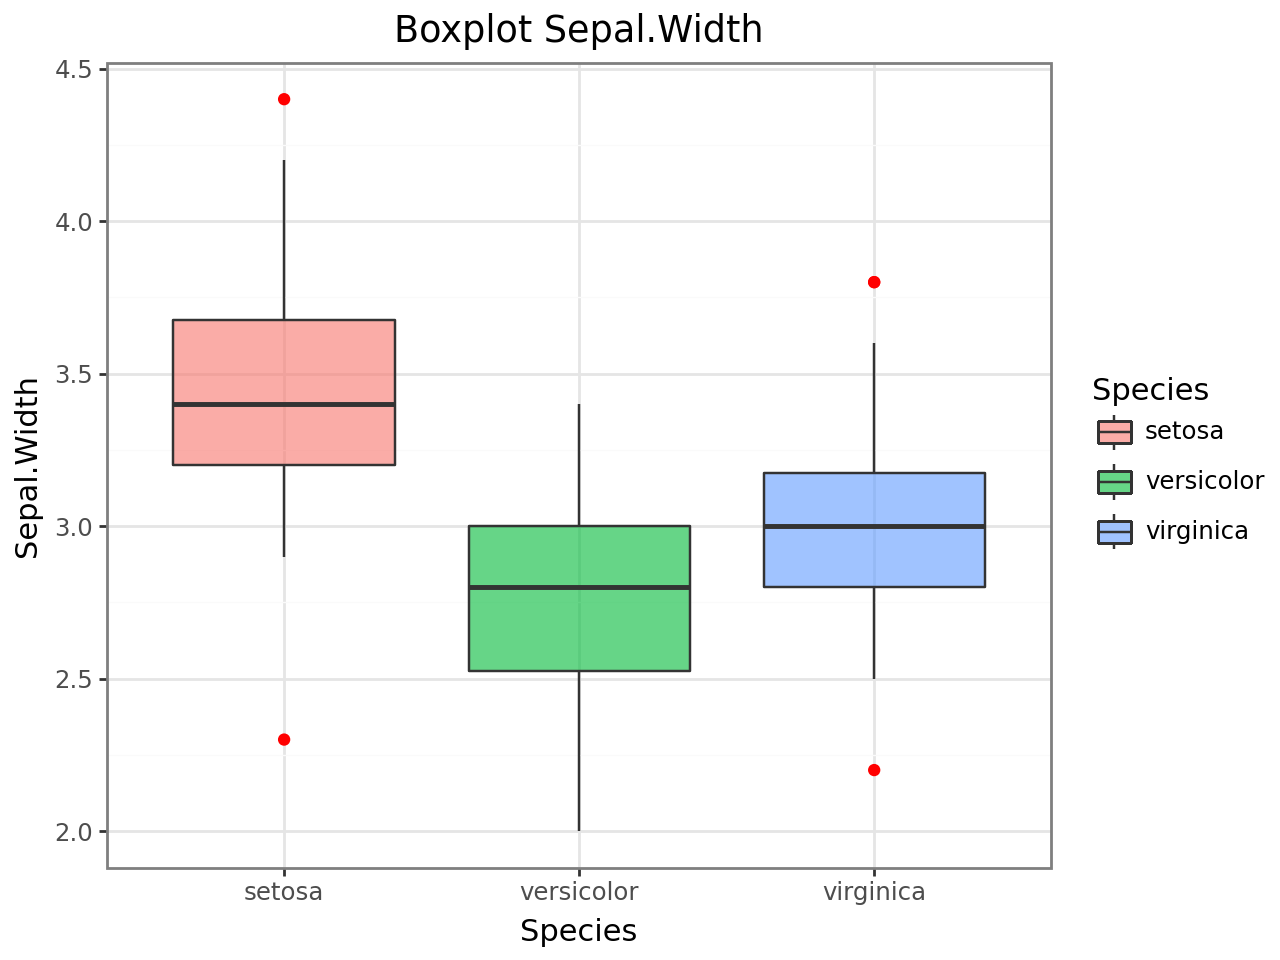

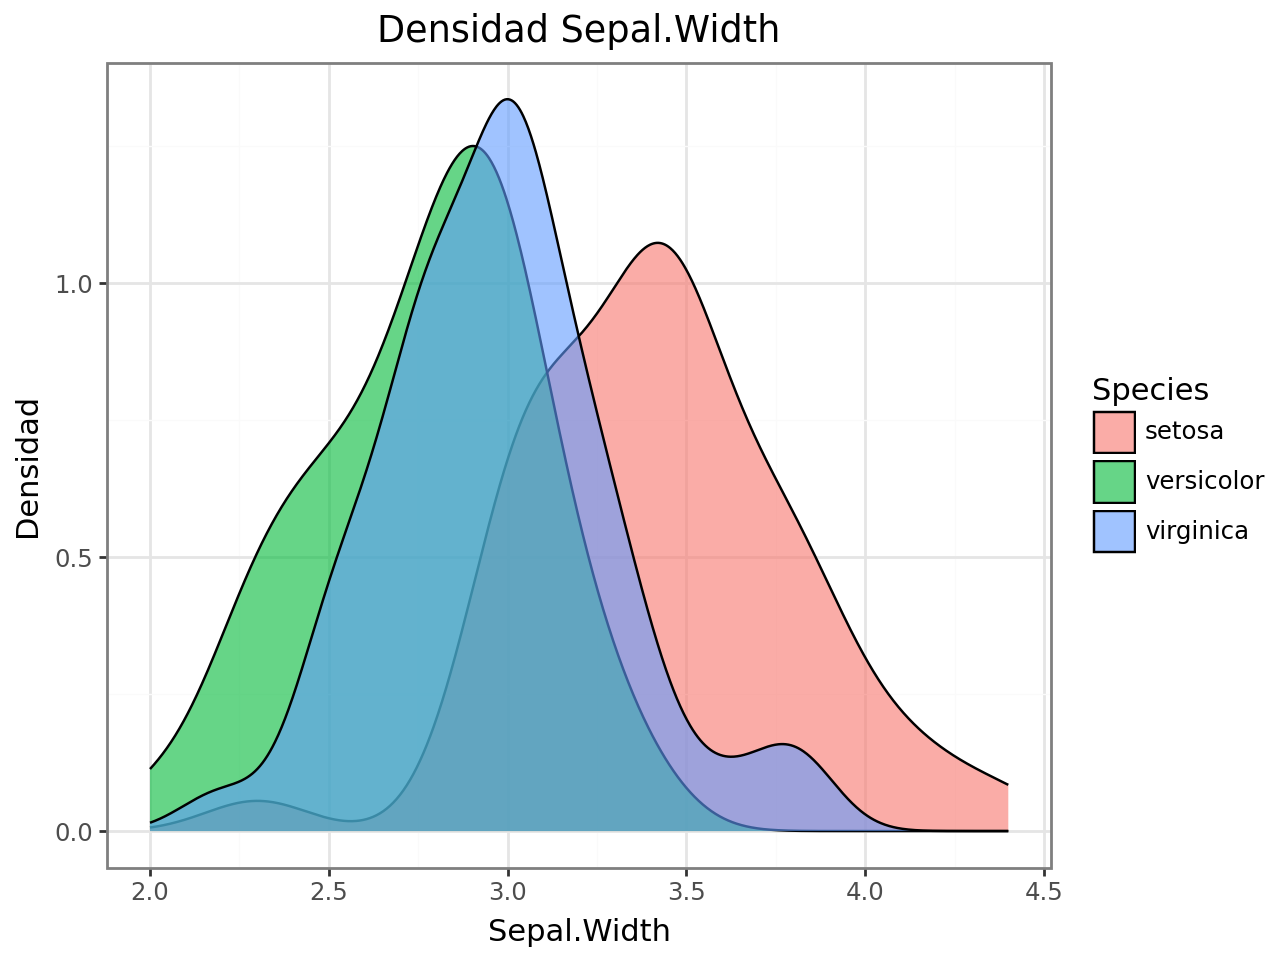

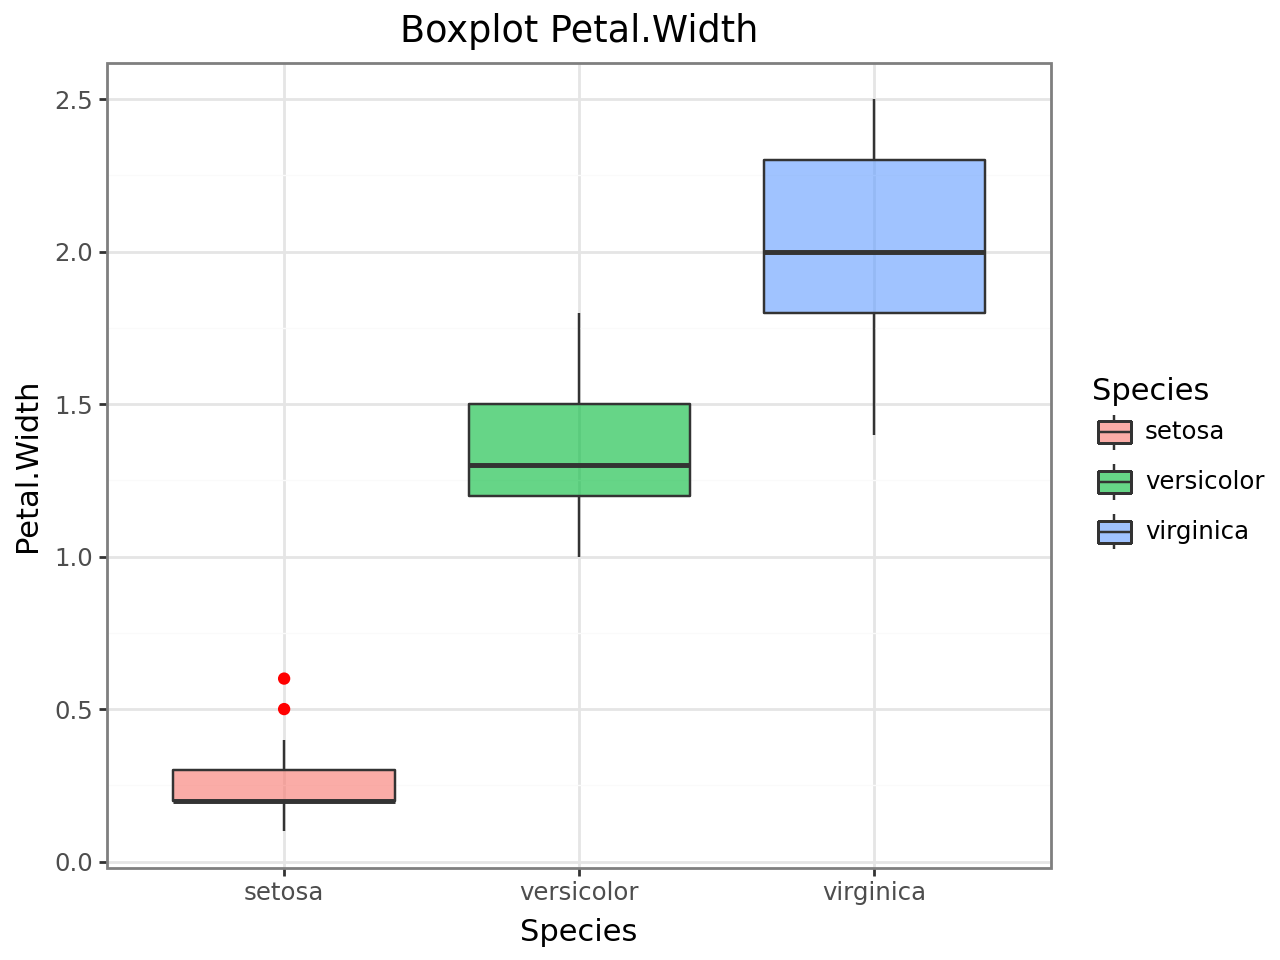

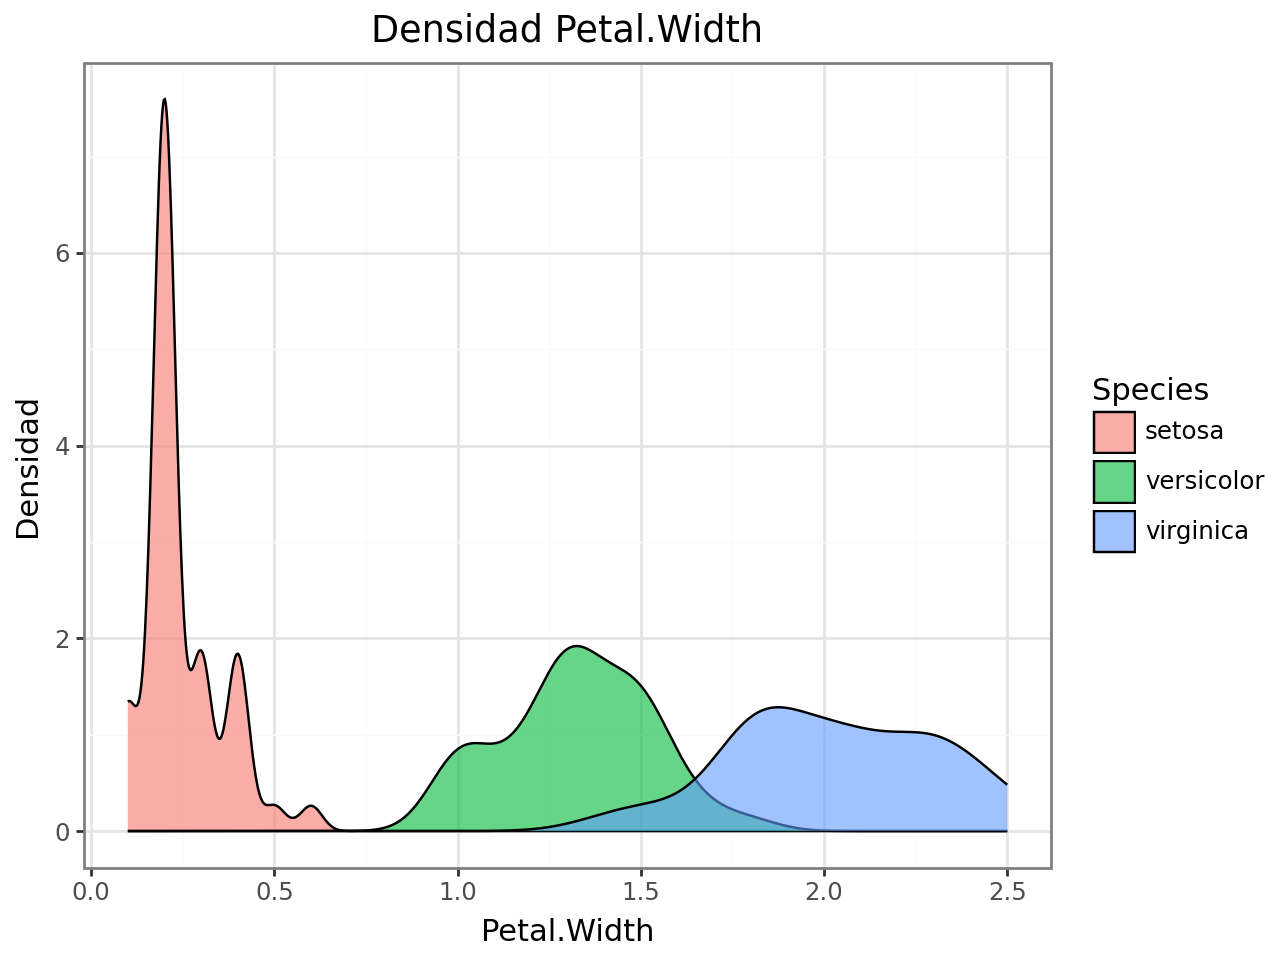

In [12]:
analisis.plot_num("Species")

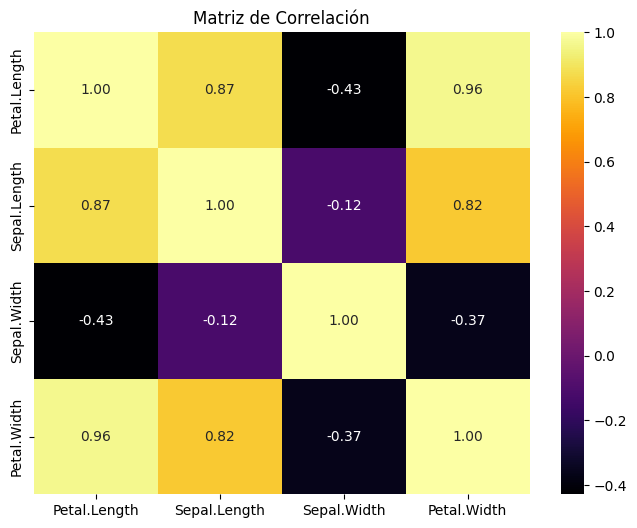

In [13]:
analisis.corr_matrix()

In [14]:
def andrews_curve(df, cat_col): 
    # Definimos la paleta personalizada
    palette = ["#3163de", "#de3163", "#63de31"]

    plt.figure(figsize=(10,6))
    andrews_curves(df, class_column=cat_col, colormap=ListedColormap(palette), alpha=0.6)
    plt.title('Curvas de Andrews', fontsize=14)
    plt.xlabel('t (función de Fourier)')
    plt.ylabel('Valor transformado')
    plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
    plt.show()

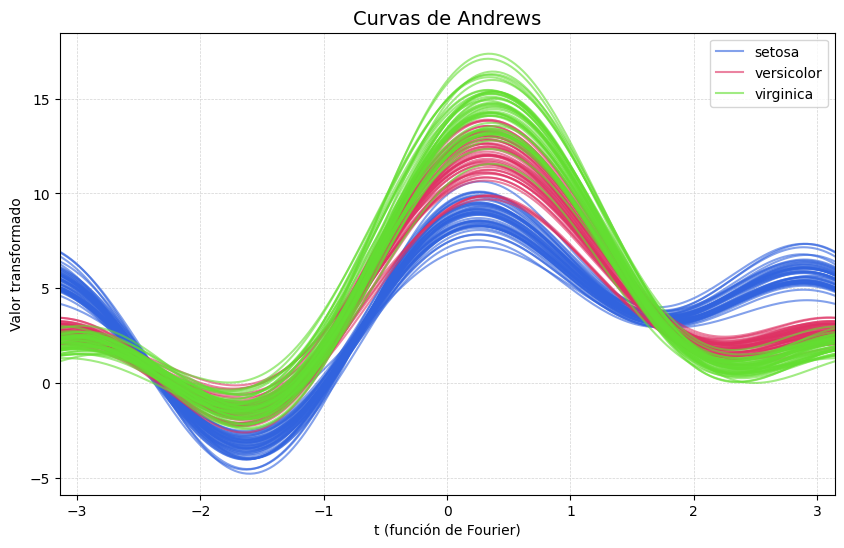

In [15]:
andrews_curve(df, "Species")

### Valores atípicos

In [16]:
#Usaremos minima covarianza
def outliers_mcd(df, contamination=0.05, random_state=1989, support_fraction=None):
    model = MCD(contamination=contamination, random_state=random_state, support_fraction=support_fraction)
    model.fit(df)
    preds = model.predict(df)
    return df[preds == 1]  #detectar

In [17]:
df_outliers = outliers_mcd(df[var_num])

In [18]:
#Visualizamos en el df original
df.loc[df_outliers.index]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
41,4.500,2.300,1.300,0.300,setosa
107,7.300,2.900,6.300,1.800,virginica
114,5.800,2.800,5.100,2.400,virginica
117,7.700,3.800,6.700,2.200,virginica
122,7.700,2.800,6.700,2.000,virginica
131,7.900,3.800,6.400,2.000,virginica
134,6.100,2.600,5.600,1.400,virginica
141,6.900,3.100,5.100,2.300,virginica


De lo anterior podemos decir lo siguiente: 

* Hay fuerte correlación entre longitud y ancho del petalo. 
* Hay una gran diferencia entre Setosa y los otros dos grupos, los cuales se mezclan un poco más.
* Hay valores atípicos que pertenecen en su mayoria a virginica, pero no los quitaremos al tener muy pocos datos y no parecer tan alejados.

## Modelado

### Split, codificación, escalamiento

In [19]:
def recode_species(x):
    if x == "setosa":
        return 0
    elif x == "virginica":
        return 1
    else:
        return 2

In [20]:
df["Species"] = df["Species"].map(recode_species)

In [21]:
y = df["Species"]
X = df.drop(columns=["Species"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1989)

#### Modelo LDA

In [23]:
lda = LinearDiscriminantAnalysis()

In [24]:
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

#### Métricas

In [25]:
#Predicción
y_pred_train = lda.predict(X_train)
y_pred_test = lda.predict(X_test)
y_prob_test = lda.predict_proba(X_test)

In [27]:
# Suponiendo que y_train tiene más de 2 clases
classes = np.unique(y_train)

# Definimos una función wrapper para AUC multiclase
def multiclass_auc(y_true, y_pred_proba):
    y_true_bin = label_binarize(y_true, classes=classes)
    return roc_auc_score(y_true_bin, y_pred_proba, multi_class='ovr', average='macro')

# Definimos el scorer personalizado
auc_scorer = make_scorer(multiclass_auc, needs_proba=True)

In [28]:
# Cross-validation con 5 folds
scores = cross_val_score(
    lda, X_train, y_train,
    cv=5,
    scoring=auc_scorer,
    n_jobs=-1
)

print(f"AUC Media: {np.mean(scores)}, Mediana: {np.median(scores)} desv:{np.std(scores, ddof = 1)}")

AUC Media: 0.9986394557823128, Mediana: 1.0 desv:0.0030422693571425245


In [29]:
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

In [31]:
# Sensibilidad (Recall promedio)
sens_train = recall_score(y_train, y_pred_train, average='macro')
sens_test = recall_score(y_test, y_pred_test, average='macro')

In [32]:
# Especificidad promedio
def specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    spec = []
    for i in range(len(cm)):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec.append(tn / (tn + fp))
    return np.mean(spec)

spec_train = specificity(y_train, y_pred_train)
spec_test = specificity(y_test, y_pred_test)

In [34]:
# AUC
y_test_bin = label_binarize(y_test, classes=classes)
auc_test = roc_auc_score(y_test_bin, y_prob_test, multi_class='ovr')

In [35]:
print(f"Accuracy Entrenamiento: {acc_train:.3f}")
print(f"Accuracy Prueba:        {acc_test:.3f}")
print(f"Sensibilidad (Recall) Train: {sens_train:.3f}")
print(f"Sensibilidad (Recall) Test:  {sens_test:.3f}")
print(f"Especificidad Train:    {spec_train:.3f}")
print(f"Especificidad Test:     {spec_test:.3f}")
print(f"AUC (Test):             {auc_test:.3f}")

Accuracy Entrenamiento: 0.971
Accuracy Prueba:        1.000
Sensibilidad (Recall) Train: 0.972
Sensibilidad (Recall) Test:  1.000
Especificidad Train:    0.986
Especificidad Test:     1.000
AUC (Test):             1.000


C:\Users\raulb\AppData\Local\Temp\ipykernel_4656\2262124543.py:37: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.


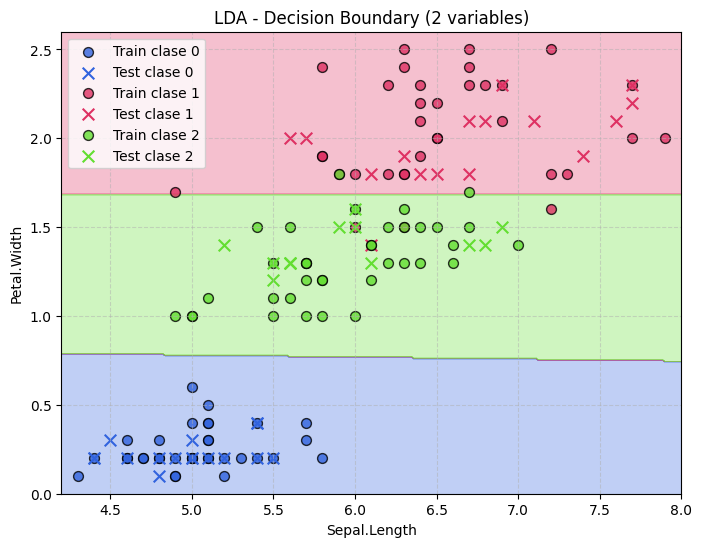

In [41]:
# Paleta personalizada
palette = ["#3163de", "#de3163", "#63de31"]
cmap_light = ListedColormap(palette)
cmap_bold = palette

# Seleccionamos las dos primeras variables para graficar en 2D
feature1 = X_train.columns[0]
feature2 = X_train.columns[3]

# Creamos una copia 2D de los datos
X_train_2d = X_train[[feature1, feature2]].values
X_test_2d = X_test[[feature1, feature2]].values

# Entrenamos un nuevo modelo LDA solo con las dos primeras variables
lda_2d = LinearDiscriminantAnalysis()
lda_2d.fit(X_train_2d, y_train)

# Creamos la malla para los límites de decisión
x_min, x_max = X_train_2d[:, 0].min() - 0.1, X_train_2d[:, 0].max() + 0.1
y_min, y_max = X_train_2d[:, 1].min() - 0.1, X_train_2d[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predicciones sobre la malla
Z = lda_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficamos las regiones de decisión
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

# Graficamos los puntos de entrenamiento y prueba
for i, color in enumerate(cmap_bold):
    plt.scatter(X_train_2d[y_train == i, 0],
                X_train_2d[y_train == i, 1],
                label=f'Train clase {i}', edgecolor='k', marker='o', s=50, color=color, alpha=0.8)
    plt.scatter(X_test_2d[y_test == i, 0],
                X_test_2d[y_test == i, 1],
                label=f'Test clase {i}', edgecolor='k', marker='x', s=70, color=color)

# Etiquetas
plt.title("LDA - Decision Boundary (2 variables)")
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()